In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/KaggleDataset/ISICDataset.zip" -d "/content/data/"
print("Extrated files")

Extrated files


In [ ]:
import os
os.system("pip install -q timm grad-cam shap")

0

In [ ]:
KAGGLE_INPUT   = "/content/data"
TRAIN_HDF5     = f"{KAGGLE_INPUT}/train-image.hdf5"
INDEX_PATH     = "/content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/final_dataset_index.csv"
SAVE_DIR       = "/content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/maxvit-fusion-standalone-colab-fix-15-version3"
MODEL_PATH     = f"{SAVE_DIR}/maxvit_tiny_fusion_best.pth"      # best weights only (for inference)
CKPT_PATH      = f"{SAVE_DIR}/maxvit_tiny_fusion_checkpoint.pth" # full resumable checkpoint
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
RESUME_CKPT = None #"/content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/maxvit-fusion-standalone-colab-fix-15-version3/maxvit_tiny_fusion_checkpoint.pth"

In [ ]:
import h5py, io, random
import numpy as np
import pandas as pd
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import GradScaler, autocast

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    f1_score, accuracy_score, average_precision_score,
    precision_recall_curve
)

import shap
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget

In [ ]:
DEVICE    = torch.device("cuda")
MULTI_GPU = torch.cuda.device_count() >= 2
print(f"GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {props.name}  VRAM: {props.total_memory/1e9:.1f} GB")

GPUs: 1
  GPU 0: Tesla T4  VRAM: 15.6 GB


In [ ]:
# ── Probe MaxViT feature dim ───────────────────────────────────────────────────
_probe = timm.create_model("maxvit_tiny_tf_224", pretrained=False, num_classes=0)
_out   = _probe(torch.randn(1, 3, 224, 224))
print(f"\nMaxViT-Tiny feature dim: {_out.shape[1]}")  # should be 512
MAXVIT_FEAT_DIM = _out.shape[1]
del _probe, _out


MaxViT-Tiny feature dim: 512


In [ ]:
# ── Config ─────────────────────────────────────────────────────────────────────
CONFIG = {
    # Training
    "batch_size":        16,     # per-GPU micro-batch; effective batch = 16×4=64
    "grad_accum_steps":   4,
    "epochs":            30,
    "lr":                1e-4,
    "weight_decay":      1e-4,
    "patience":           5,
    "warmup_epochs":      3,

    # Data
    # num_workers=0 → single process, one HDF5 handle, no RAM spike from workers.
    # prefetch_factor is intentionally ABSENT — it raises ValueError at 0 workers.
    "num_workers":        4,
    "pin_memory":     True,

    # Sampler: draw 2 × minority_count samples per epoch (≈400–500 steps)
    # instead of the full dataset (~9300 steps / ~10 hrs).
    "sampler_multiplier": 2,

    # Validation subsampling — FIX for validation OOM.
    # Running inference on the full val set (potentially 50k+ images) in one pass
    # with num_workers=0 loads everything sequentially into RAM and kills the kernel.
    # Instead, evaluate on a random subset each epoch for speed and safety.
    # Set to None to use the full val set (only safe if your val set is small).
    "val_subsample":   4000,    # evaluate on 4000 val samples per epoch

    # AMP
    "amp":             True,

    # Loss
    "focal_gamma":        2,
    "focal_alpha":     0.85,
    "cutmix_prob":     0.30,

    # Mid-epoch checkpoint every N optimizer steps
    "ckpt_every_steps": 100,

    # Threshold / evaluation
    "min_sensitivity":  0.80,
    "pauc_min_tpr":     0.80,
}


In [ ]:
# ── Metrics ────────────────────────────────────────────────────────────────────
def compute_pauc(y_true, y_prob, min_tpr=0.80):
    """Robust pAUC above min_tpr (official ISIC 2024 style, range 0.0 - 0.20)"""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob, pos_label=1)

    # Find the first index where TPR >= min_tpr
    idx = np.where(tpr >= min_tpr)[0]
    if len(idx) < 2:
        return 0.0

    start = idx[0]

    # Include a small buffer before the cutoff for better trapezoidal integration
    start = max(0, start - 1)

    fpr_part = fpr[start:]
    tpr_part = tpr[start:]

    # Compute partial AUC
    pauc = auc(fpr_part, tpr_part)
    return float(pauc)

def find_threshold_at_sensitivity(y_true, y_prob, min_sens=0.80):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    valid = np.where(tpr >= min_sens)[0]
    if len(valid) == 0:
        return float(thresholds[-1])
    return float(thresholds[valid[np.argmin(fpr[valid])]])

def full_metrics(y_true, y_pred, y_prob, threshold):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "Accuracy":    accuracy_score(y_true, y_pred),
        "Sensitivity": tp / (tp + fn + 1e-8),
        "Specificity": tn / (tn + fp + 1e-8),
        "PPV":         tp / (tp + fp + 1e-8),
        "NPV":         tn / (tn + fn + 1e-8),
        "F1":          f1_score(y_true, y_pred),
        "AUROC":       roc_auc_score(y_true, y_prob),
        "pAUC":        compute_pauc(y_true, y_prob, CONFIG["pauc_min_tpr"]),
        "AP":          average_precision_score(y_true, y_prob),
        "Threshold":   threshold,
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
    }

In [ ]:
# ── Metadata preprocessing ─────────────────────────────────────────────────────
def preprocess_metadata(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["age_approx"] = df["age_approx"].fillna(df["age_approx"].median())
    age_min, age_max = df["age_approx"].min(), df["age_approx"].max()
    df["age_approx"] = (df["age_approx"] - age_min) / (age_max - age_min + 1e-8)
    df["sex"] = df["sex"].map({"male": 0, "female": 1}).fillna(0.0)
    if "clin_size_long_diam_mm" in df.columns:
        p99 = df["clin_size_long_diam_mm"].quantile(0.99)
        df["clin_size_long_diam_mm"] = (
            df["clin_size_long_diam_mm"]
            .fillna(df["clin_size_long_diam_mm"].median())
            .clip(0, p99) / (p99 + 1e-8)
        )
    else:
        df["clin_size_long_diam_mm"] = 0.0
    df = pd.get_dummies(df, columns=["anatom_site_general"])
    return df

In [ ]:
# ── Dataset ────────────────────────────────────────────────────────────────────
class ISICDataset(Dataset):
    def __init__(self, df, hdf5_path, transform=None):
        self.df        = df.reset_index(drop=True)
        self.hdf5_path = hdf5_path
        self.transform = transform
        self.meta_cols = (
            [c for c in df.columns if c.startswith("anatom_site_general")]
            + ["age_approx", "sex", "clin_size_long_diam_mm"]
        )
        self._hdf5 = None

    def _get_hdf5(self):
        if self._hdf5 is None:
            # rdcc_nbytes=0 disables chunk cache to save RAM
            self._hdf5 = h5py.File(self.hdf5_path, "r", rdcc_nbytes=0)
        return self._hdf5

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Open fresh each time (slightly slower but no leaks)
        with h5py.File(self.hdf5_path, "r", rdcc_nbytes=0) as f:
            raw = f[row["isic_id"]][()]
        image = np.array(Image.open(io.BytesIO(raw)).convert("RGB"))
        if self.transform:
            image = self.transform(image=image)["image"]
        meta  = torch.tensor(row[self.meta_cols].values.astype(np.float32))
        label = torch.tensor(float(row["target"]), dtype=torch.float32)
        return image, meta, label

In [ ]:
# ── Augmentation ───────────────────────────────────────────────────────────────
train_tf = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=25, p=0.5),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.5),
    A.HueSaturationValue(10, 20, 10, p=0.3),
    A.ElasticTransform(alpha=1, sigma=50, p=0.2),
    A.CoarseDropout(max_holes=4, max_height=32, max_width=32, p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])
val_tf = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

/tmp/ipykernel_2930/2064941289.py:10: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=32, max_width=32, p=0.2),


In [ ]:
# ── CutMix ─────────────────────────────────────────────────────────────────────
def cutmix_batch(images, labels, prob=0.3):
    if random.random() > prob:
        return images, labels, labels, 1.0
    lam        = np.random.beta(1.0, 1.0)
    B, C, H, W = images.shape
    perm       = torch.randperm(B)
    cut_h      = int(H * np.sqrt(1 - lam))
    cut_w      = int(W * np.sqrt(1 - lam))
    cx, cy     = random.randint(0, W), random.randint(0, H)
    x1, x2    = max(cx - cut_w // 2, 0), min(cx + cut_w // 2, W)
    y1, y2    = max(cy - cut_h // 2, 0), min(cy + cut_h // 2, H)
    images[:, :, y1:y2, x1:x2] = images[perm, :, y1:y2, x1:x2]
    lam_adj    = 1 - (y2 - y1) * (x2 - x1) / (H * W)
    return images, labels, labels[perm], lam_adj

In [ ]:
# ── Loss ───────────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2, alpha=0.85):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        bce  = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        prob = torch.sigmoid(logits)
        pt   = torch.where(targets == 1, prob, 1 - prob)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()

In [ ]:
# ── Model ──────────────────────────────────────────────────────────────────────
class MetadataMLP(nn.Module):
    def __init__(self, in_dim, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, out_dim), nn.LayerNorm(out_dim), nn.GELU(),
        )
        self.skip = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()

    def forward(self, x):
        return self.net(x) + self.skip(x)

class MaxViTFusion(nn.Module):
    def __init__(self, meta_dim, feat_dim=512, meta_out=128):
        super().__init__()
        self.backbone = timm.create_model(
            "maxvit_tiny_tf_224", pretrained=True, num_classes=0
        )
        self.meta_net   = MetadataMLP(meta_dim, meta_out)
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim + meta_out, 256), nn.LayerNorm(256),
            nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 64), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, image, meta):
        return self.classifier(
            torch.cat([self.backbone(image), self.meta_net(meta)], dim=1)
        )

    def get_gradcam_layer(self):
        return self.backbone.stages[-1].blocks[-1]

In [ ]:
# ── Data setup ─────────────────────────────────────────────────────────────────
df       = pd.read_csv(INDEX_PATH)
df       = preprocess_metadata(df)
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print(f"\nSplit sizes — Train: {len(train_df):,}  Val: {len(val_df):,}  "
      f"Test: {len(test_df):,}")

pos = int(train_df["target"].sum())
neg = len(train_df) - pos
print(f"Class balance — Malignant: {pos:,}  Benign: {neg:,}  Ratio 1:{neg//pos}")

train_ds = ISICDataset(train_df, TRAIN_HDF5, train_tf)
val_ds   = ISICDataset(val_df,   TRAIN_HDF5, val_tf)
test_ds  = ISICDataset(test_df,  TRAIN_HDF5, val_tf)
meta_dim = len(train_ds.meta_cols)
print(f"\nMetadata features ({meta_dim}): {train_ds.meta_cols}")


Split sizes — Train: 298,560  Val: 53,629  Test: 48,870
Class balance — Malignant: 271  Benign: 298,289  Ratio 1:1100

Metadata features (8): ['anatom_site_general_anterior torso', 'anatom_site_general_head/neck', 'anatom_site_general_lower extremity', 'anatom_site_general_posterior torso', 'anatom_site_general_upper extremity', 'age_approx', 'sex', 'clin_size_long_diam_mm']


In [ ]:
# ── Sampler + DataLoaders ──────────────────────────────────────────────────────
wts       = train_df["target"].apply(lambda x: 1/pos if x == 1 else 1/neg)
sampler_n = CONFIG["sampler_multiplier"] * pos * 2
sampler   = WeightedRandomSampler(wts.values, num_samples=sampler_n, replacement=True)
print(f"\nTrain sampler: {sampler_n:,} samples/epoch "
      f"(~{sampler_n // CONFIG['batch_size']:,} steps/epoch)")

# NOTE: prefetch_factor intentionally not passed — invalid when num_workers=0.
loader_kw = dict(
    batch_size         = CONFIG["batch_size"],
    num_workers        = CONFIG["num_workers"],
    pin_memory         = CONFIG["pin_memory"],
    persistent_workers = CONFIG["num_workers"] > 0,  # keep workers alive between epochs
    prefetch_factor    = 2,                           # only valid when num_workers > 0
)
train_loader = DataLoader(train_ds, sampler=sampler, **loader_kw)

# FIX: Validation subsampling to prevent OOM during val inference.
# The full val set can be 50k+ images. Reading them all sequentially in the main
# process (num_workers=0) builds up RAM until the kernel is killed.
# A random 4000-sample subset gives a reliable metric estimate with ~10× less RAM.
if CONFIG["val_subsample"] and CONFIG["val_subsample"] < len(val_ds):
    val_indices = torch.randperm(len(val_ds))[:CONFIG["val_subsample"]].tolist()
    val_subset  = torch.utils.data.Subset(val_ds, val_indices)
    val_loader  = DataLoader(val_subset, shuffle=False, **loader_kw)
    print(f"Val loader:   {CONFIG['val_subsample']:,} samples (subsampled from {len(val_ds):,})")
else:
    val_loader  = DataLoader(val_ds, shuffle=False, **loader_kw)
    print(f"Val loader:   {len(val_ds):,} samples (full val set)")

test_loader = DataLoader(test_ds, shuffle=False, **loader_kw)

steps_per_epoch = len(train_loader)
print(f"Steps/epoch:  {steps_per_epoch:,}  "
      f"(effective batch {CONFIG['batch_size'] * CONFIG['grad_accum_steps']})")



Train sampler: 1,084 samples/epoch (~67 steps/epoch)
Val loader:   4,000 samples (subsampled from 53,629)
Steps/epoch:  68  (effective batch 64)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
# ── Model + optimiser ──────────────────────────────────────────────────────────
model = MaxViTFusion(meta_dim, feat_dim=MAXVIT_FEAT_DIM).to(DEVICE)
if MULTI_GPU:
    model = nn.DataParallel(model)
    print("\n✓ DataParallel — 2× T4")

def get_param_groups(model):
    raw = model
    if hasattr(raw, "module"):    raw = raw.module
    if hasattr(raw, "_orig_mod"): raw = raw._orig_mod
    return [
        {"params": list(raw.backbone.parameters()),                              "lr": CONFIG["lr"] / 10},
        {"params": list(raw.meta_net.parameters()) + list(raw.classifier.parameters()), "lr": CONFIG["lr"]},
    ]

optimizer = optim.AdamW(get_param_groups(model), weight_decay=CONFIG["weight_decay"])

# FIX: OneCycleLR steps_per_epoch updated to match the capped sampler.
# Using the old ~9300 steps value here would make the LR schedule wrong.
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr       = [CONFIG["lr"] / 10, CONFIG["lr"]],
    steps_per_epoch = steps_per_epoch,
    epochs       = CONFIG["epochs"],
    pct_start    = CONFIG["warmup_epochs"] / CONFIG["epochs"],
    anneal_strategy = "cos",
)
scaler    = GradScaler(enabled=CONFIG["amp"])
criterion = FocalLoss(CONFIG["focal_gamma"], CONFIG["focal_alpha"])

In [ ]:
# ── Resume logic ───────────────────────────────────────────────────────────────
start_epoch  = 0
best_pauc    = 0.0
counter      = 0
global_step  = 0   # total optimizer steps taken (used for mid-epoch checkpointing)
history      = {"train_loss": [], "val_auroc": [], "val_pauc": [], "lr_backbone": []}

if RESUME_CKPT and os.path.exists(RESUME_CKPT):
    print(f"\nResuming from checkpoint: {RESUME_CKPT}")
    ckpt = torch.load(RESUME_CKPT, map_location=DEVICE, weights_only=False)

    raw  = model
    if hasattr(raw, "module"):    raw = raw.module
    if hasattr(raw, "_orig_mod"): raw = raw._orig_mod
    raw.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    scaler.load_state_dict(ckpt["scaler"])
    start_epoch = ckpt["epoch"]
    best_pauc   = ckpt["best_pauc"]
    counter     = ckpt.get("counter", 0)
    global_step = ckpt.get("global_step", 0)
    history     = ckpt["history"]
    print(f"  → Resumed at epoch {start_epoch}/{CONFIG['epochs']}, "
          f"best pAUC: {best_pauc:.4f}, patience counter: {counter}")
elif RESUME_CKPT:
    print(f"\nWarning: RESUME_CKPT='{RESUME_CKPT}' not found — starting fresh.")

In [ ]:
# ── Helper: save full checkpoint ───────────────────────────────────────────────
def save_checkpoint(epoch, is_best=False, tag=""):
    raw = model
    if hasattr(raw, "module"):    raw = raw.module
    if hasattr(raw, "_orig_mod"): raw = raw._orig_mod
    ckpt = {
        "epoch":       epoch,
        "model_state": raw.state_dict(),
        "optimizer":   optimizer.state_dict(),
        "scheduler":   scheduler.state_dict(),
        "scaler":      scaler.state_dict(),
        "best_pauc":   best_pauc,
        "counter":     counter,
        "global_step": global_step,
        "history":     history,
    }
    torch.save(ckpt, CKPT_PATH)
    if tag:
        torch.save(ckpt, f"{SAVE_DIR}/ckpt_{tag}.pth")
    if is_best:
        torch.save(raw.state_dict(), MODEL_PATH)

In [ ]:
# ── Training loop ──────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("Training: MaxViT-Tiny + Metadata Fusion")
print(f"Epochs: {start_epoch} → {CONFIG['epochs']}  |  "
      f"Steps/epoch: {steps_per_epoch}  |  "
      f"Grad accum: {CONFIG['grad_accum_steps']}")
print("="*60)

for epoch in range(start_epoch, CONFIG["epochs"]):
    model.train()
    running_loss = 0.0
    accum_step   = 0

    optimizer.zero_grad()

    for batch_idx, (images, meta, labels) in enumerate(
            tqdm(train_loader, desc=f"Epoch {epoch+1:02d}")):

        images = images.to(DEVICE, non_blocking=True)
        meta   = meta.to(DEVICE,   non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        images, la, lb, lam = cutmix_batch(images, labels, CONFIG["cutmix_prob"])
        la = la.unsqueeze(1)
        lb = lb.unsqueeze(1)

        with autocast("cuda", enabled=CONFIG["amp"]):
            out  = model(images, meta)
            loss = (lam * criterion(out, la) + (1 - lam) * criterion(out, lb))
            loss = loss / CONFIG["grad_accum_steps"]

        scaler.scale(loss).backward()
        running_loss += loss.item() * CONFIG["grad_accum_steps"]
        accum_step   += 1

        if accum_step == CONFIG["grad_accum_steps"]:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
            accum_step   = 0
            global_step += 1

            if global_step % CONFIG["ckpt_every_steps"] == 0:
                save_checkpoint(epoch, tag=f"epoch{epoch+1:02d}_step{global_step}")
                print(f"\n  [mid-epoch ckpt @ step {global_step}]")

    if accum_step > 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        optimizer.zero_grad()
        global_step += 1

    avg_loss = running_loss / len(train_loader)

    # ── Validation ─────────────────────────────────────────────────────────────
    model.eval()
    y_true_v, y_prob_v = [], []

    with torch.no_grad():
        for images, meta, labels in val_loader:
            with autocast("cuda", enabled=CONFIG["amp"]):
                probs = torch.sigmoid(
                    model(images.to(DEVICE, non_blocking=True),
                          meta.to(DEVICE,   non_blocking=True))
                ).cpu().float().numpy().flatten()
            y_prob_v.extend(probs)
            y_true_v.extend(labels.numpy())
            # FIX: explicitly delete tensors and free VRAM each batch
            del images, meta, labels, probs

    torch.cuda.empty_cache()

    val_auroc = roc_auc_score(y_true_v, y_prob_v)
    val_pauc  = compute_pauc(y_true_v, y_prob_v, CONFIG["pauc_min_tpr"])
    curr_lr   = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(avg_loss)
    history["val_auroc"].append(val_auroc)
    history["val_pauc"].append(val_pauc)
    history["lr_backbone"].append(curr_lr)

    print(f"Epoch {epoch+1:02d} | Loss {avg_loss:.4f} | "
          f"AUROC {val_auroc:.4f} | pAUC {val_pauc:.4f} | "
          f"LR {curr_lr:.2e}")

    is_best = val_pauc > best_pauc
    if is_best:
        best_pauc = val_pauc
        counter   = 0
        print(f"  → New best pAUC: {best_pauc:.4f}")
    else:
        counter += 1

    save_checkpoint(epoch + 1, is_best=is_best, tag=f"epoch{epoch+1:02d}")

    if is_best:
        print(f"  → Best model weights saved")

    if counter >= CONFIG["patience"]:
        print("Early stopping.")
        break



Training: MaxViT-Tiny + Metadata Fusion
Epochs: 0 → 30  |  Steps/epoch: 68  |  Grad accum: 4


Epoch 01:   0%|          | 0/68 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 01: 100%|██████████| 68/68 [00:20<00:00,  3.27it/s]


Epoch 01 | Loss 0.1540 | AUROC 0.5721 | pAUC 0.1949 | LR 5.65e-07
  → New best pAUC: 0.1949
  → Best model weights saved


Epoch 02: 100%|██████████| 68/68 [00:23<00:00,  2.84it/s]


Epoch 02 | Loss 0.1529 | AUROC 0.5911 | pAUC 0.2241 | LR 1.05e-06
  → New best pAUC: 0.2241
  → Best model weights saved


...

Epoch 29 | Loss 0.0883 | AUROC 0.8906 | pAUC 0.7116 | LR 9.40e-06


Epoch 30:  41%|████      | 28/68 [00:26<03:32,  5.31s/it]


  [mid-epoch ckpt @ step 500]


Epoch 30: 100%|██████████| 68/68 [00:39<00:00,  1.73it/s]


Epoch 30 | Loss 0.0912 | AUROC 0.8880 | pAUC 0.7081 | LR 9.33e-06
Early stopping.


In [ ]:
# ── Threshold calibration ──────────────────────────────────────────────────────
print("\n── Threshold calibration ──")
best_model = MaxViTFusion(meta_dim, feat_dim=MAXVIT_FEAT_DIM).to(DEVICE)
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False))
best_model.eval()

y_true_v, y_prob_v = [], []
with torch.no_grad():
    for images, meta, labels in val_loader:
        with autocast("cuda", enabled=CONFIG["amp"]):
            probs = torch.sigmoid(
                best_model(images.to(DEVICE), meta.to(DEVICE))
            ).cpu().float().numpy().flatten()
        y_prob_v.extend(probs)
        y_true_v.extend(labels.numpy())

threshold = find_threshold_at_sensitivity(y_true_v, y_prob_v,
                                           CONFIG["min_sensitivity"])
print(f"Threshold: {threshold:.4f}  "
      f"(sensitivity >= {CONFIG['min_sensitivity']:.0%} on val set)")


── Threshold calibration ──
Threshold: 0.4050  (sensitivity >= 80% on val set)


In [ ]:
# ── Test evaluation ────────────────────────────────────────────────────────────
print("\n── Test set evaluation ──")
y_true_t, y_pred_t, y_prob_t = [], [], []

with torch.no_grad():
    for images, meta, labels in test_loader:
        with autocast("cuda", enabled=CONFIG["amp"]):
            probs = torch.sigmoid(
                best_model(images.to(DEVICE), meta.to(DEVICE))
            ).cpu().float().numpy().flatten()
        preds = (probs >= threshold).astype(int)
        y_prob_t.extend(probs)
        y_pred_t.extend(preds)
        y_true_t.extend(labels.numpy())

y_true_t = np.array(y_true_t)
y_pred_t = np.array(y_pred_t)
y_prob_t = np.array(y_prob_t)
metrics  = full_metrics(y_true_t, y_pred_t, y_prob_t, threshold)

print("║     MaxViT-Tiny + Fusion — RESULTS   ║")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"║  {k:<16} {v:>10.4f}          ║")
    else:
        print(f"║  {k:<16} {str(v):>10}          ║")


── Test set evaluation ──


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


║     MaxViT-Tiny + Fusion — RESULTS   ║
║  Accuracy             0.7765          ║
║  Sensitivity          0.8308          ║
║  Specificity          0.7764          ║
║  PPV                  0.0049          ║
║  NPV                  0.9997          ║
║  F1                   0.0098          ║
║  AUROC                0.8905          ║
║  pAUC                 0.7937          ║
║  AP                   0.0538          ║
║  Threshold            0.4050          ║
║  TP                       54          ║
║  FP                    10912          ║
║  FN                       11          ║
║  TN                    37893          ║


In [ ]:
# ── Go / No-Go ────────────────────────────────────────────────────────────────
print("\n── Distillation Go/No-Go Assessment ──")
THRESHOLDS = {
    "pAUC":        (0.10, "Minimum acceptable"),
    "AUROC":       (0.88, "Minimum acceptable"),
    "Sensitivity": (0.80, "Must meet — screening requirement"),
}
go = True
for metric, (threshold_val, reason) in THRESHOLDS.items():
    val    = metrics[metric]
    passed = val >= threshold_val
    status = "✓ PASS" if passed else "✗ FAIL"
    if not passed:
        go = False
    print(f"  {status}  {metric}: {val:.4f} (need >= {threshold_val})  [{reason}]")

print(f"\n{'→ GO: Proceed to distillation.' if go else '→ NO-GO: Improve baseline first.'}")

if not go:
    print("\nSuggestions:")
    if metrics["pAUC"] < 0.10:
        print("  • pAUC too low — try focal_alpha=0.90 or sampler_multiplier=3")
    if metrics["Sensitivity"] < 0.80:
        print("  • Sensitivity too low — try lower min_sensitivity=0.75")
    if metrics["AUROC"] < 0.88:
        print("  • AUROC low — check for overfitting in training curves")



── Distillation Go/No-Go Assessment ──
  ✓ PASS  pAUC: 0.7937 (need >= 0.1)  [Minimum acceptable]
  ✓ PASS  AUROC: 0.8905 (need >= 0.88)  [Minimum acceptable]
  ✓ PASS  Sensitivity: 0.8308 (need >= 0.8)  [Must meet — screening requirement]

→ GO: Proceed to distillation.


In [ ]:
# ── Save results CSV ──────────────────────────────────────────────────────────
results_df = pd.DataFrame([{
    "Model": "MaxViT-Tiny + Fusion",
    "Params_M": 31,
    "pAUC": metrics["pAUC"], "AUROC": metrics["AUROC"],
    "Sensitivity": metrics["Sensitivity"], "Specificity": metrics["Specificity"],
    "F1": metrics["F1"], "AP": metrics["AP"],
    "Threshold": threshold,
    "TP": metrics["TP"], "FP": metrics["FP"],
    "FN": metrics["FN"], "TN": metrics["TN"],
}])
results_df.to_csv(f"{SAVE_DIR}/maxvit_results.csv", index=False)
print(f"\nResults saved → {SAVE_DIR}/maxvit_results.csv")


Results saved → /content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/maxvit-fusion-standalone-colab-fix-15-version3/maxvit_results.csv


In [ ]:
# ── Save results to CSV (for dissertation table) ───────────────────────────────
results_df = pd.DataFrame([{
    "Model":       "MaxViT-Tiny + Fusion",
    "Params_M":    31,
    "pAUC":        metrics["pAUC"],
    "AUROC":       metrics["AUROC"],
    "Sensitivity": metrics["Sensitivity"],
    "Specificity": metrics["Specificity"],
    "F1":          metrics["F1"],
    "AP":          metrics["AP"],
    "Threshold":   threshold,
    "TP": metrics["TP"], "FP": metrics["FP"],
    "FN": metrics["FN"], "TN": metrics["TN"],
}])
results_df.to_csv(f"{SAVE_DIR}/maxvit_results.csv", index=False)
print(f"\nResults saved to {SAVE_DIR}/maxvit_results.csv")



Results saved to /content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/maxvit-fusion-standalone-colab-fix-15-version3/maxvit_results.csv


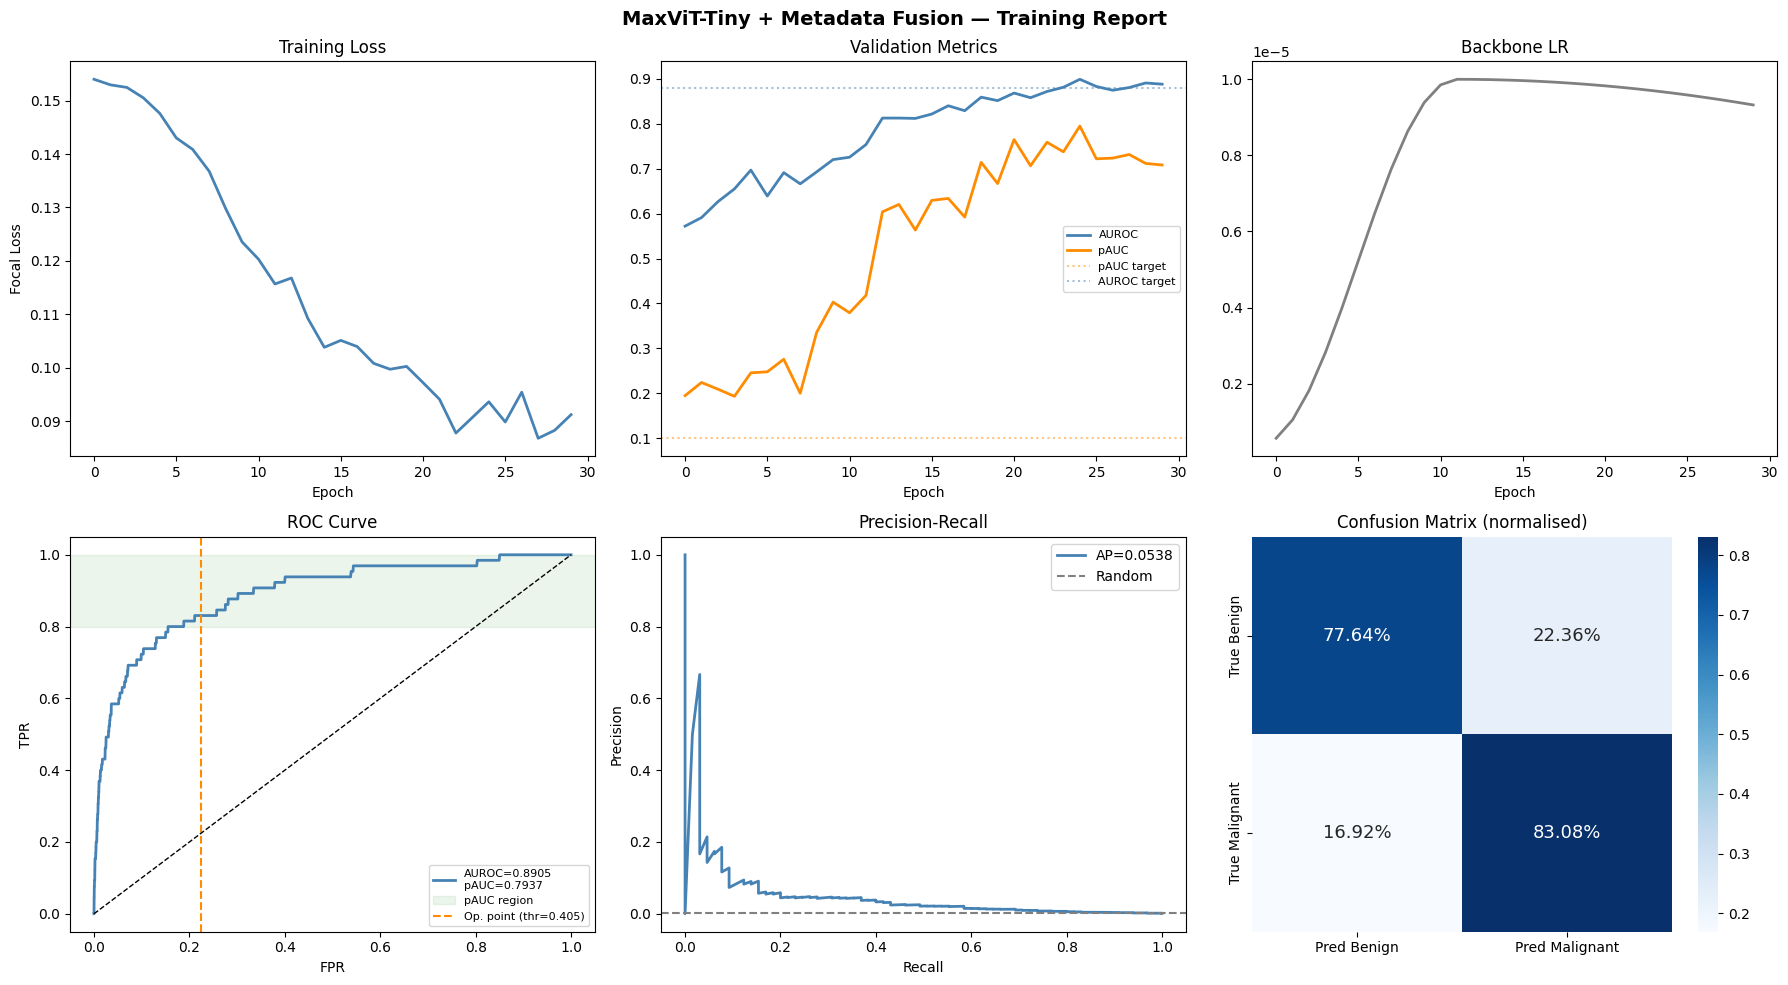

In [ ]:
# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("MaxViT-Tiny + Metadata Fusion — Training Report",
             fontsize=14, fontweight="bold")

axes[0,0].plot(history["train_loss"], color="steelblue", lw=2)
axes[0,0].set_title("Training Loss"); axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Focal Loss")

axes[0,1].plot(history["val_auroc"], label="AUROC",  color="steelblue", lw=2)
axes[0,1].plot(history["val_pauc"],  label="pAUC",   color="darkorange", lw=2)
axes[0,1].axhline(0.10, color="darkorange", linestyle=":", alpha=0.5, label="pAUC target")
axes[0,1].axhline(0.88, color="steelblue",  linestyle=":", alpha=0.5, label="AUROC target")
axes[0,1].set_title("Validation Metrics"); axes[0,1].legend(fontsize=8)
axes[0,1].set_xlabel("Epoch")

axes[0,2].plot(history["lr_backbone"], color="grey", lw=2)
axes[0,2].set_title("Backbone LR"); axes[0,2].set_xlabel("Epoch")
axes[0,2].ticklabel_format(style="sci", axis="y", scilimits=(0,0))

fpr, tpr, _ = roc_curve(y_true_t, y_prob_t)
axes[1,0].plot(fpr, tpr, color="steelblue", lw=2,
               label=f"AUROC={metrics['AUROC']:.4f}\npAUC={metrics['pAUC']:.4f}")
axes[1,0].axhspan(CONFIG["pauc_min_tpr"], 1.0, alpha=0.08, color="green",
                   label=f"pAUC region")
axes[1,0].axvline(1 - metrics["Specificity"], color="darkorange",
                   linestyle="--", label=f"Op. point (thr={threshold:.3f})")
axes[1,0].plot([0,1],[0,1],"k--",lw=1)
axes[1,0].set_xlabel("FPR"); axes[1,0].set_ylabel("TPR")
axes[1,0].set_title("ROC Curve"); axes[1,0].legend(fontsize=8)

prec, rec, _ = precision_recall_curve(y_true_t, y_prob_t)
axes[1,1].plot(rec, prec, color="steelblue", lw=2, label=f"AP={metrics['AP']:.4f}")
axes[1,1].axhline(pos / (pos + neg), color="grey", linestyle="--", label="Random")
axes[1,1].set_xlabel("Recall"); axes[1,1].set_ylabel("Precision")
axes[1,1].set_title("Precision-Recall"); axes[1,1].legend()

cm      = confusion_matrix(y_true_t, y_pred_t)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", ax=axes[1,2],
            xticklabels=["Pred Benign","Pred Malignant"],
            yticklabels=["True Benign","True Malignant"],
            annot_kws={"size": 13})
axes[1,2].set_title("Confusion Matrix (normalised)")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/maxvit_training_report.png", dpi=150, bbox_inches="tight")
plt.show()

  0%|          | 0/1 [00:00<?, ?it/s]

  SHAP skipped (sample 0, class 1): CUDA out of memory. Tried to allocate 7.42 GiB. GPU 0 has a total capacity of 14.56 GiB of which 2.16 GiB is free. Including non-PyTorch memory, this process has 12.40 GiB memory in use. Of the allocated memory 10.67 GiB is allocated by PyTorch, and 1.58 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Report — True: MALIGNANT | Score: 0.7628 | FLAGGED


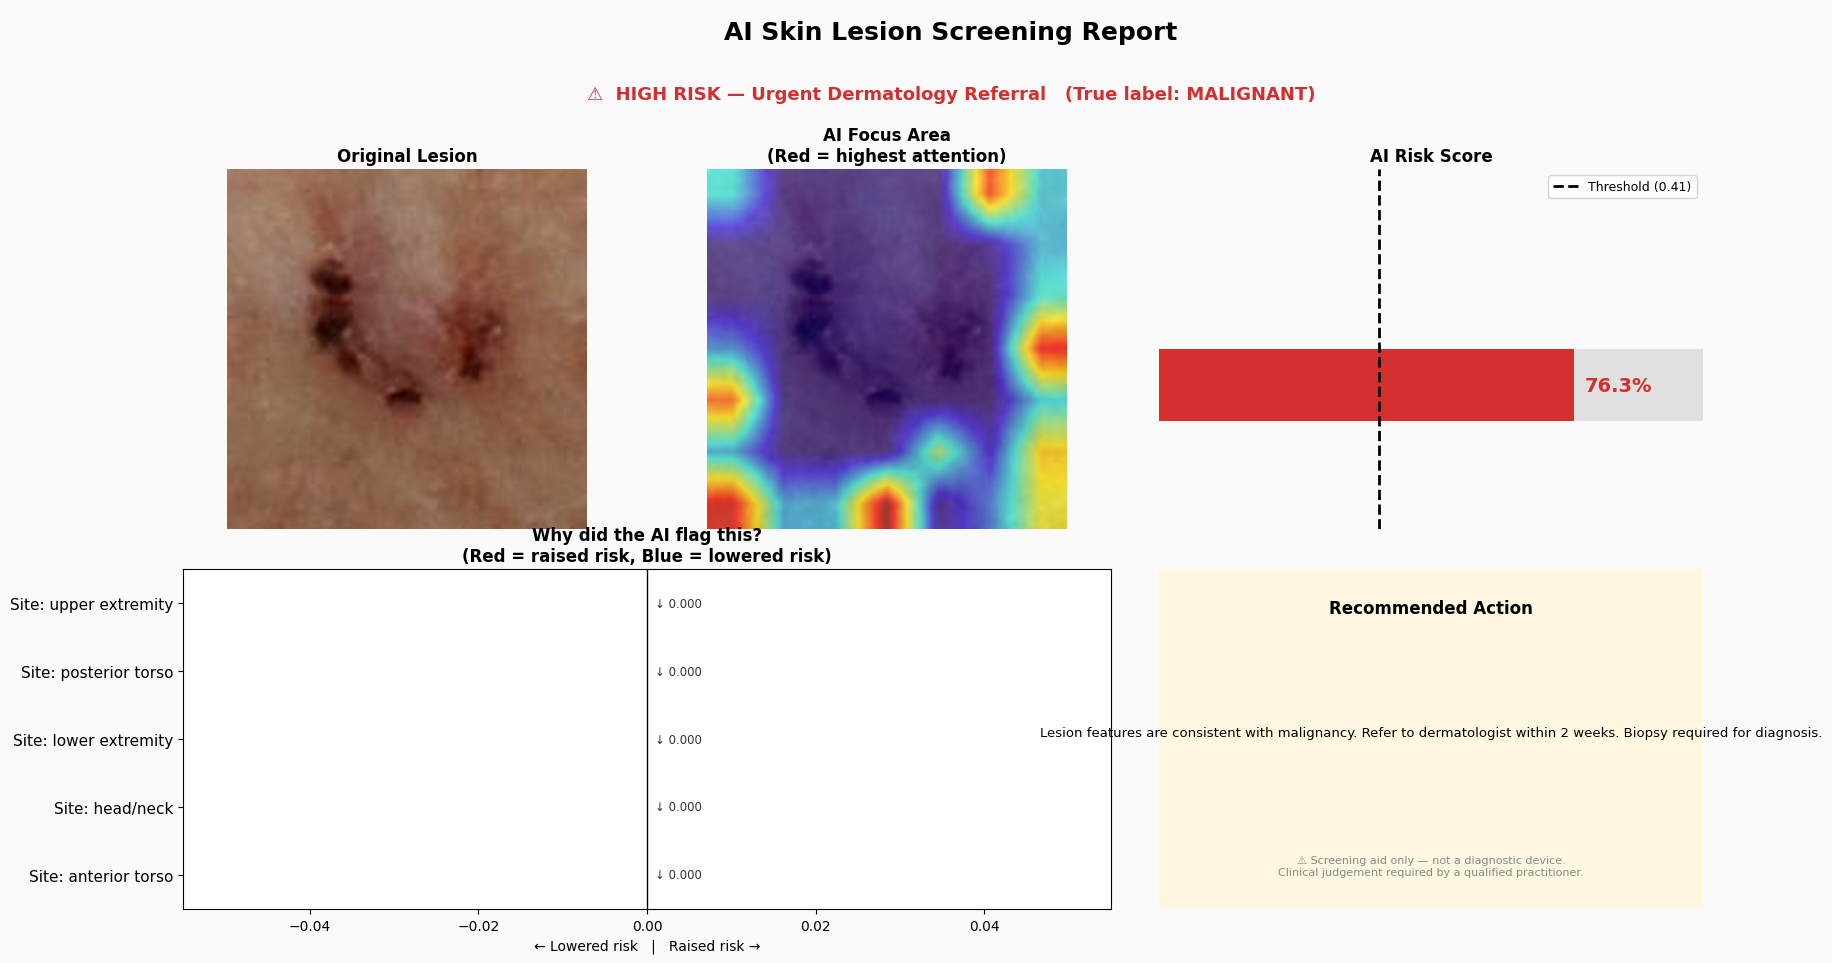

  Saved: /content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/maxvit-fusion-standalone-colab-fix-15-version3/report_MALIGNANT_0.png


  0%|          | 0/1 [00:00<?, ?it/s]

  SHAP skipped (sample 1, class 1): CUDA out of memory. Tried to allocate 7.42 GiB. GPU 0 has a total capacity of 14.56 GiB of which 2.16 GiB is free. Including non-PyTorch memory, this process has 12.40 GiB memory in use. Of the allocated memory 5.11 GiB is allocated by PyTorch, and 7.15 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Report — True: MALIGNANT | Score: 0.2376 | not flagged


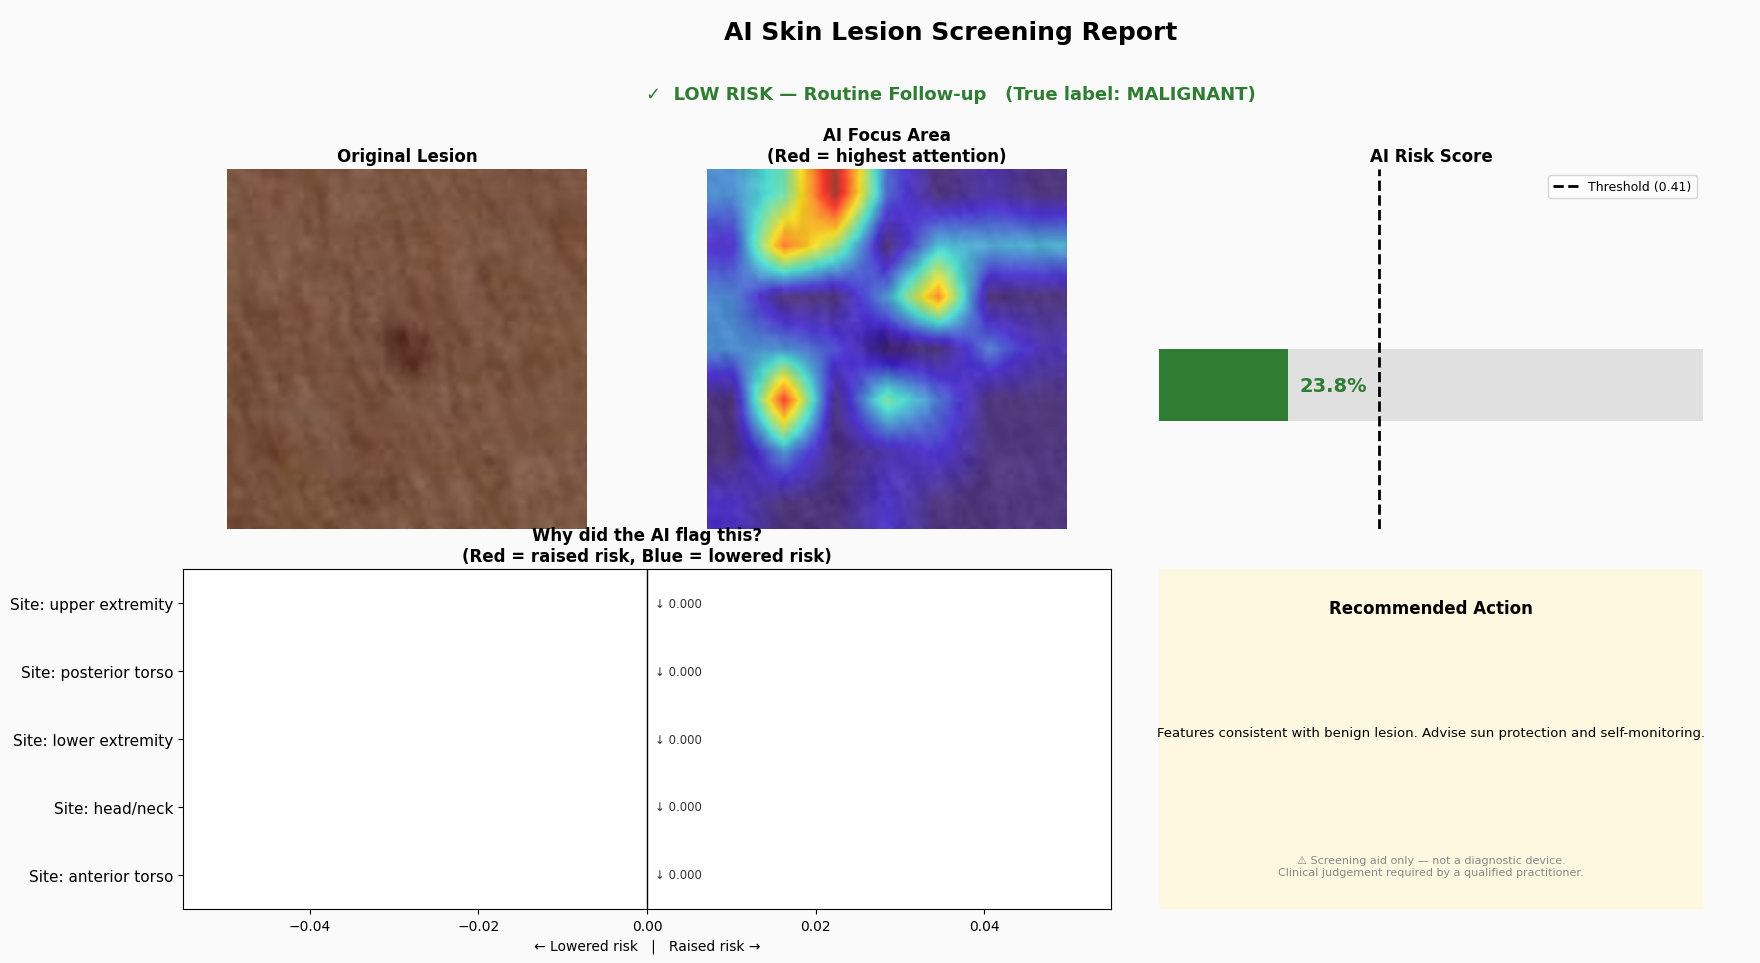

  Saved: /content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/maxvit-fusion-standalone-colab-fix-15-version3/report_MALIGNANT_1.png


  0%|          | 0/1 [00:00<?, ?it/s]

  SHAP skipped (sample 2, class 1): CUDA out of memory. Tried to allocate 7.42 GiB. GPU 0 has a total capacity of 14.56 GiB of which 2.16 GiB is free. Including non-PyTorch memory, this process has 12.40 GiB memory in use. Of the allocated memory 5.11 GiB is allocated by PyTorch, and 7.15 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Report — True: MALIGNANT | Score: 0.6871 | FLAGGED


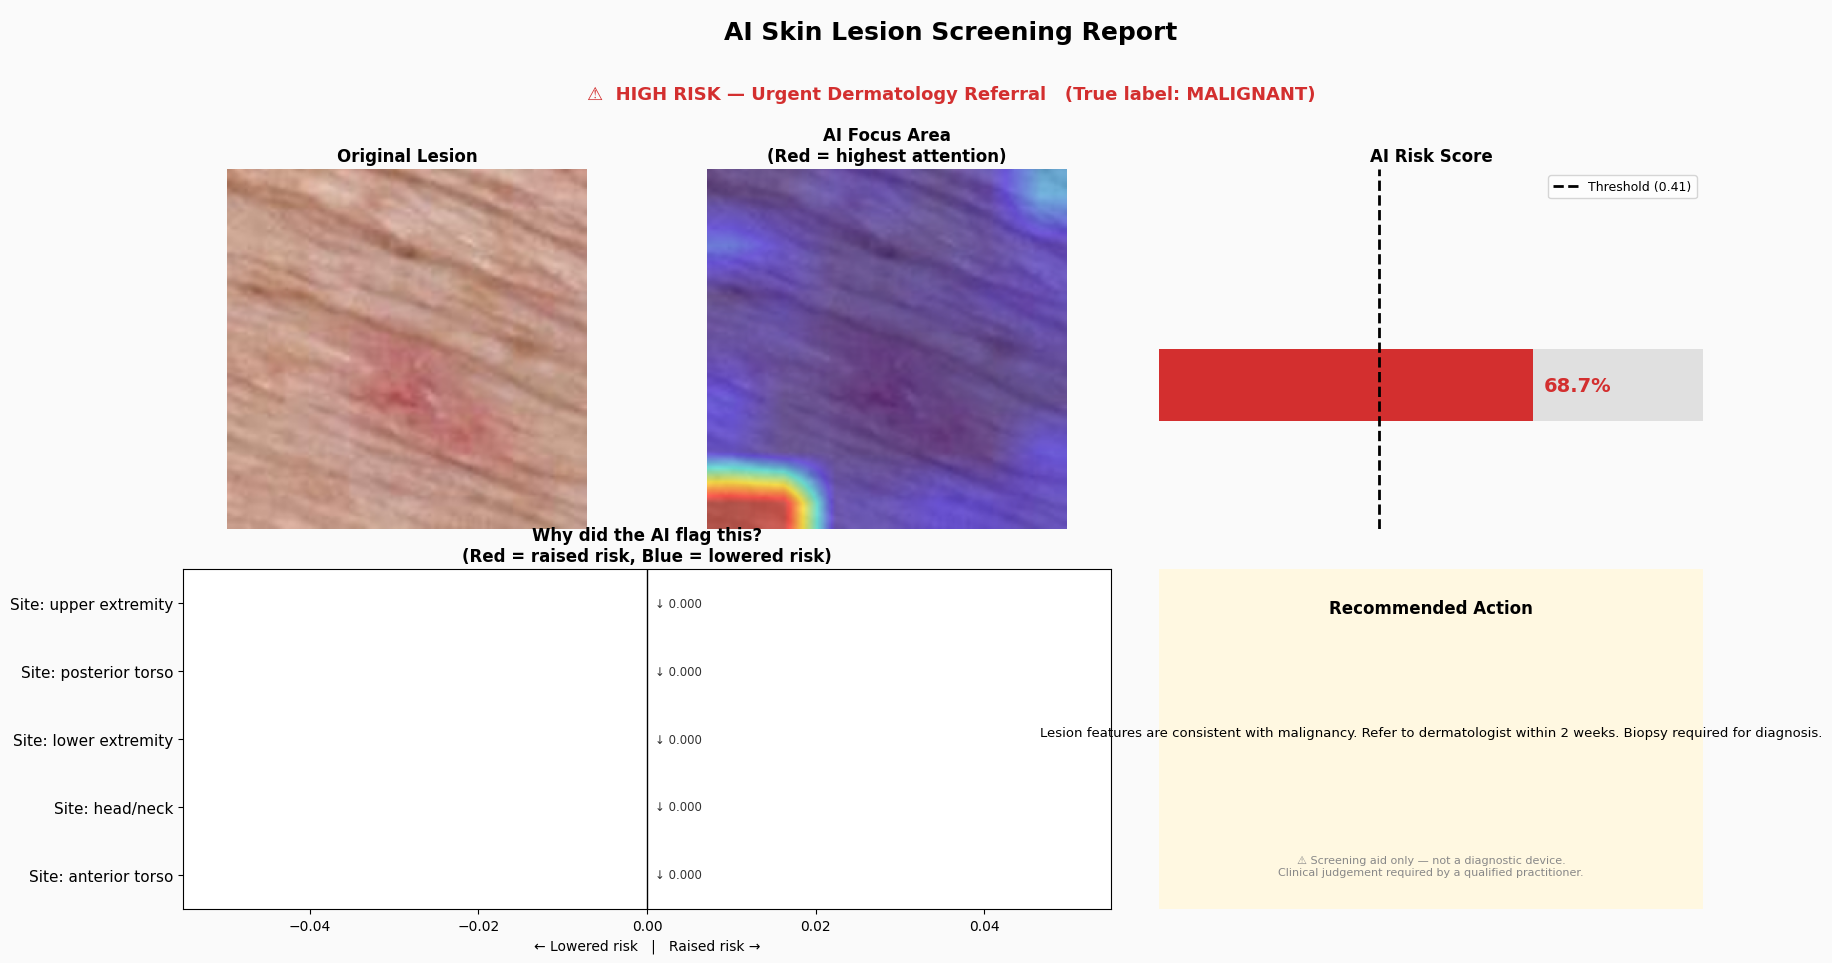

  Saved: /content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/maxvit-fusion-standalone-colab-fix-15-version3/report_MALIGNANT_2.png


  0%|          | 0/1 [00:00<?, ?it/s]

  SHAP skipped (sample 0, class 0): CUDA out of memory. Tried to allocate 7.42 GiB. GPU 0 has a total capacity of 14.56 GiB of which 2.16 GiB is free. Including non-PyTorch memory, this process has 12.40 GiB memory in use. Of the allocated memory 5.11 GiB is allocated by PyTorch, and 7.15 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Report — True: BENIGN | Score: 0.4566 | FLAGGED


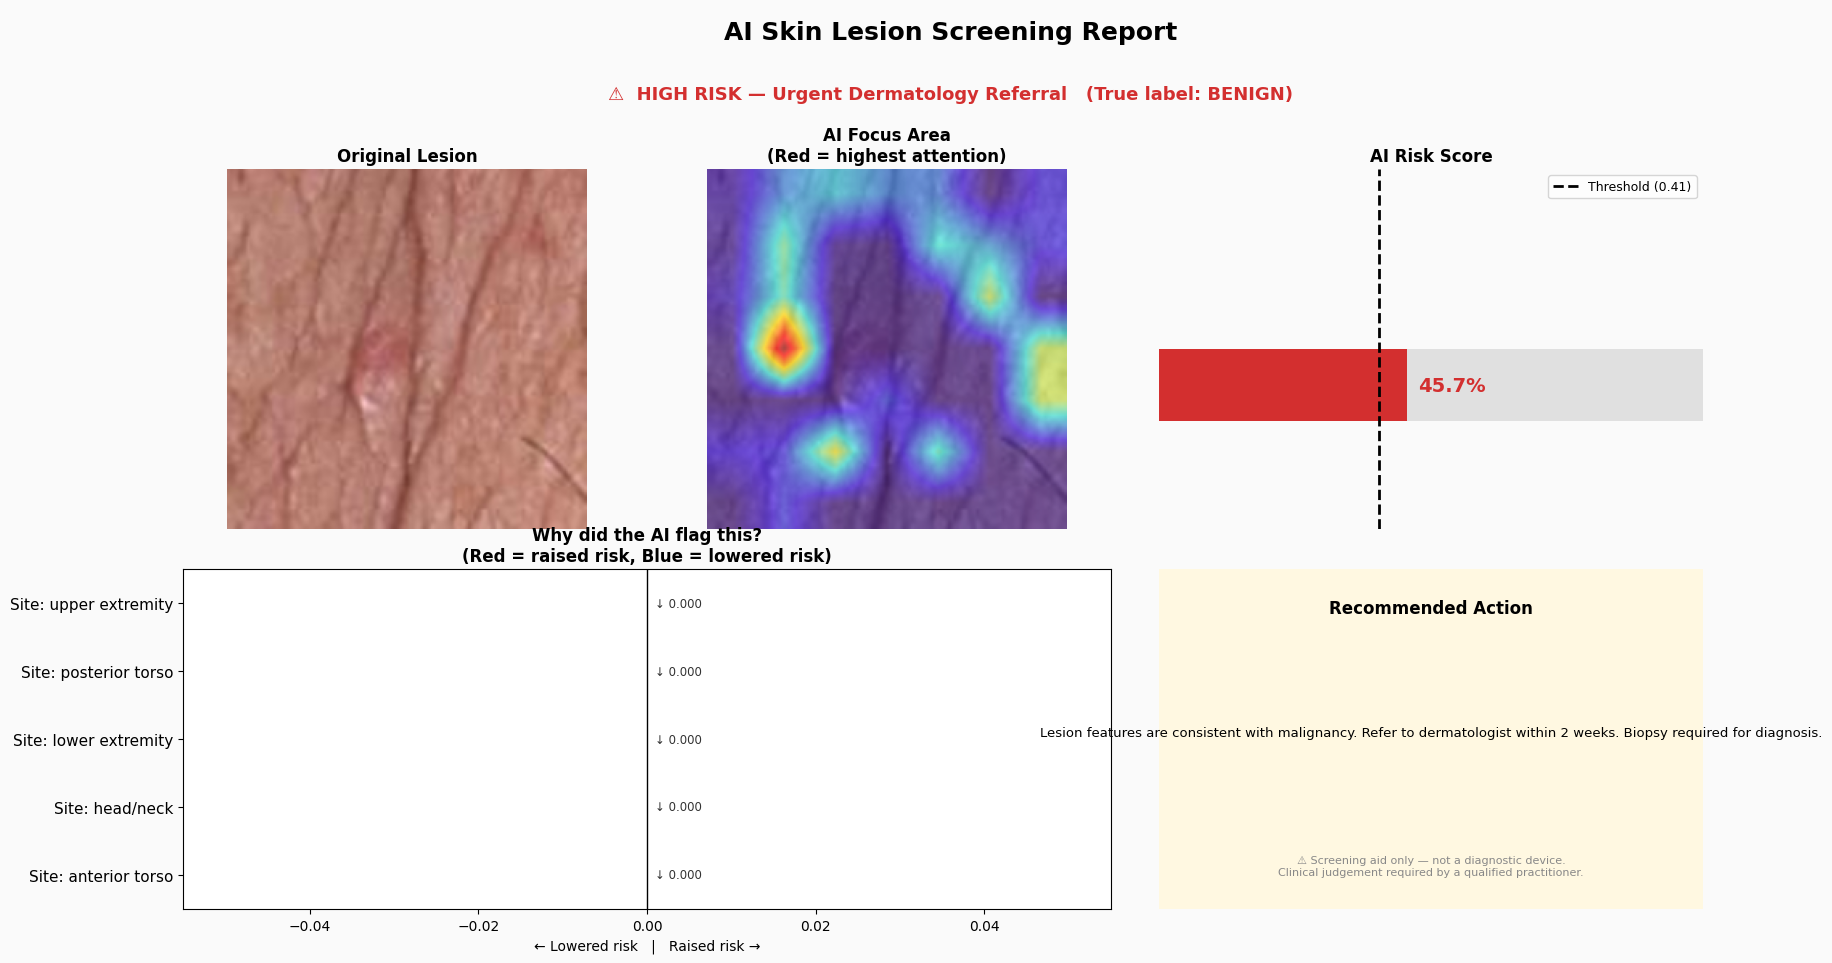

  Saved: /content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/maxvit-fusion-standalone-colab-fix-15-version3/report_BENIGN_0.png

✓ Complete. All outputs in /content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/maxvit-fusion-standalone-colab-fix-15-version3
  Model weights:  /content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/maxvit-fusion-standalone-colab-fix-15-version3/maxvit_tiny_fusion_best.pth
  Checkpoint:     /content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/maxvit-fusion-standalone-colab-fix-15-version3/maxvit_tiny_fusion_checkpoint.pth  ← use this to resume
  Results CSV:    /content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/maxvit-fusion-standalone-colab-fix-15-version3/maxvit_results.csv
  Training plot:  /content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/maxvit-fusion-standalone-colab-fix-15-version3/maxvit_training_report.p

In [ ]:
# ── XAI: GradCAM + SHAP ───────────────────────────────────────────────────────
class MaxViTGradCAMWrapper(nn.Module):
    def __init__(self, model, meta_tensor):
        super().__init__()
        self.model = model
        self.meta  = meta_tensor

    def forward(self, image):
        return self.model(image, self.meta.expand(image.shape[0], -1))

def get_gradcam_overlay(model, img_tensor, meta_tensor, orig_np):
    model.eval()
    wrapper       = MaxViTGradCAMWrapper(model, meta_tensor)
    target_layers = [model.backbone.stages[-1].blocks[-1]]
    cam           = GradCAM(model=wrapper, target_layers=target_layers)
    grayscale     = cam(input_tensor=img_tensor,
                        targets=[BinaryClassifierOutputTarget(0)])[0]
    rgb = orig_np.astype(np.float32) / 255.0
    return show_cam_on_image(rgb, grayscale, use_rgb=True), grayscale

def get_shap_values(model, val_meta_cpu, meta_col_names, device=DEVICE):
    """val_meta_cpu must be a CPU tensor — KernelExplainer calls .numpy()."""
    model.eval()
    dummy_img = torch.zeros(1, 3, 224, 224).to(device)

    def meta_predict(meta_np):
        meta_t = torch.tensor(meta_np, dtype=torch.float32).to(device)
        with torch.no_grad():
            out = model(dummy_img.expand(meta_t.shape[0], -1, -1, -1), meta_t)
        return torch.sigmoid(out).cpu().numpy().flatten()

    explainer = shap.KernelExplainer(meta_predict, val_meta_cpu[:10].numpy())
    shap_vals = explainer.shap_values(val_meta_cpu[[0]].numpy(), nsamples=100)[0]
    return dict(zip(meta_col_names, shap_vals))

def generate_report_card(orig_np, cam_overlay, shap_dict, prob, threshold,
                          true_label, save_path):
    if prob >= threshold:
        risk_label = "⚠  HIGH RISK — Urgent Dermatology Referral"
        risk_color = "#d32f2f"
        action     = ("Lesion features are consistent with malignancy. Refer to "
                      "dermatologist within 2 weeks. Biopsy required for diagnosis.")
    elif prob >= threshold * 0.6:
        risk_label = "⚡  MODERATE RISK — Review in 4–6 Weeks"
        risk_color = "#f57c00"
        action     = ("Atypical features present. Photograph and follow up "
                      "in 4–6 weeks. Consider dermoscopy review.")
    else:
        risk_label = "✓  LOW RISK — Routine Follow-up"
        risk_color = "#2e7d32"
        action     = ("Features consistent with benign lesion. Advise sun "
                      "protection and self-monitoring.")

    top_shap = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:5]
    fig = plt.figure(figsize=(16, 10))
    fig.patch.set_facecolor("#fafafa")

    ax_h = fig.add_axes([0, 0.88, 1, 0.12]); ax_h.axis("off")
    ax_h.text(0.5, 0.75, "AI Skin Lesion Screening Report",
              ha="center", fontsize=18, fontweight="bold")
    ax_h.text(0.5, 0.25, f"{risk_label}   (True label: {true_label})",
              ha="center", fontsize=13, color=risk_color, fontweight="bold")

    ax_o = fig.add_axes([0.02, 0.48, 0.28, 0.36])
    ax_o.imshow(orig_np); ax_o.axis("off")
    ax_o.set_title("Original Lesion", fontweight="bold")

    ax_c = fig.add_axes([0.32, 0.48, 0.28, 0.36])
    ax_c.imshow(cam_overlay); ax_c.axis("off")
    ax_c.set_title("AI Focus Area\n(Red = highest attention)", fontweight="bold")

    ax_g = fig.add_axes([0.63, 0.48, 0.34, 0.36]); ax_g.axis("off")
    ax_g.barh(0, 1.0, height=0.4, color="#e0e0e0")
    ax_g.barh(0, prob, height=0.4, color=risk_color)
    ax_g.axvline(threshold, color="black", linestyle="--", lw=2,
                 label=f"Threshold ({threshold:.2f})")
    ax_g.set_xlim(0, 1); ax_g.set_ylim(-0.8, 1.2)
    ax_g.set_title("AI Risk Score", fontweight="bold")
    ax_g.text(min(prob + 0.02, 0.82), 0, f"{prob:.1%}", va="center",
              fontweight="bold", color=risk_color, fontsize=14)
    ax_g.legend(loc="upper right", fontsize=9)

    ax_s = fig.add_axes([0.02, 0.10, 0.58, 0.34])
    names, vals = [], []
    for name, val in top_shap:
        names.append(
            name.replace("anatom_site_general_", "Site: ")
                .replace("age_approx", "Patient Age")
                .replace("sex", "Sex (F=1, M=0)")
                .replace("clin_size_long_diam_mm", "Lesion Size (mm)")
        )
        vals.append(val)
    colors = ["#d32f2f" if v > 0 else "#1976d2" for v in vals]
    ax_s.barh(range(len(vals)), vals, color=colors, height=0.55, edgecolor="white")
    ax_s.set_yticks(range(len(vals))); ax_s.set_yticklabels(names, fontsize=11)
    ax_s.axvline(0, color="black", lw=1)
    ax_s.set_title("Why did the AI flag this?\n(Red = raised risk, Blue = lowered risk)",
                   fontweight="bold")
    ax_s.set_xlabel("← Lowered risk   |   Raised risk →")
    for i, val in enumerate(vals):
        label = f"↑ +{val:.3f}" if val > 0 else f"↓ {val:.3f}"
        ax_s.text(val + (0.001 if val >= 0 else -0.001), i, label,
                  va="center", ha="left" if val >= 0 else "right",
                  fontsize=8.5, color="#333333")

    ax_a = fig.add_axes([0.63, 0.10, 0.34, 0.34]); ax_a.axis("off")
    ax_a.add_patch(mpatches.FancyBboxPatch(
        (0.03, 0.03), 0.94, 0.94, boxstyle="round,pad=0.05",
        linewidth=2.5, edgecolor=risk_color, facecolor="#fff8e1"
    ))
    ax_a.text(0.5, 0.87, "Recommended Action", ha="center",
              fontweight="bold", fontsize=12, transform=ax_a.transAxes)
    ax_a.text(0.5, 0.52, action, ha="center", va="center", fontsize=9.5,
              transform=ax_a.transAxes, multialignment="center")
    ax_a.text(0.5, 0.10,
              "⚠ Screening aid only — not a diagnostic device.\n"
              "Clinical judgement required by a qualified practitioner.",
              ha="center", fontsize=8, color="#888888",
              transform=ax_a.transAxes, multialignment="center")

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {save_path}")

# FIX: val_meta_tensor kept on CPU for SHAP
val_meta_tensor_cpu = torch.tensor(
    val_df[test_ds.meta_cols].values.astype(np.float32)
)  # CPU only

hdf5_file = h5py.File(TRAIN_HDF5, "r")
for target_class, n_samples in [(1, 3), (0, 1)]:
    indices = np.where(y_true_t == target_class)[0][:n_samples]
    for i, idx in enumerate(indices):
        row    = test_df.iloc[idx]
        raw    = hdf5_file[row["isic_id"]][()]
        orig   = np.array(Image.open(io.BytesIO(raw)).convert("RGB").resize((224, 224)))
        img_t  = val_tf(image=orig)["image"].unsqueeze(0).to(DEVICE)
        meta_t = torch.tensor(
            row[test_ds.meta_cols].values.astype(np.float32)
        ).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            prob = torch.sigmoid(best_model(img_t, meta_t)).item()

        cam_overlay, _ = get_gradcam_overlay(best_model, img_t, meta_t, orig)

        # FIX: SHAP in try/except — OOM here cannot kill saved checkpoint
        try:
            shap_vals = get_shap_values(best_model, val_meta_tensor_cpu,
                                        test_ds.meta_cols)
        except Exception as e:
            print(f"  SHAP skipped (sample {i}, class {target_class}): {e}")
            shap_vals = {col: 0.0 for col in test_ds.meta_cols}

        label_str = "MALIGNANT" if target_class == 1 else "BENIGN"
        print(f"\nReport — True: {label_str} | Score: {prob:.4f} | "
              f"{'FLAGGED' if prob >= threshold else 'not flagged'}")
        generate_report_card(
            orig, cam_overlay, shap_vals, prob, threshold, label_str,
            save_path=f"{SAVE_DIR}/report_{label_str}_{i}.png"
        )

hdf5_file.close()

print(f"\n✓ Complete. All outputs in {SAVE_DIR}")
print(f"  Model weights:  {MODEL_PATH}")
print(f"  Checkpoint:     {CKPT_PATH}  ← use this to resume")
print(f"  Results CSV:    {SAVE_DIR}/maxvit_results.csv")
print(f"  Training plot:  {SAVE_DIR}/maxvit_training_report.png")
print(f"\n  To resume in a new Kaggle session:")
print(f"    1. Add this run's output as an Input Dataset")
print(f"    2. Set RESUME_CKPT = '/kaggle/input/<dataset>/maxvit_tiny_fusion_checkpoint.pth'")
print(f"    3. Or use a specific epoch: '/kaggle/input/<dataset>/ckpt_epoch_05.pth'")
print(f"    4. Or a mid-epoch save:    '/kaggle/input/<dataset>/ckpt_epoch1_step100.pth'")
print(f"\n  If Go/No-Go passed → run knowledge_distillation_kaggle.py")
print(f"  Set TEACHER_PATH = '{MODEL_PATH}'")